# Choice Modeling: Multinomial Logit (MNL) Model

**Goal:** Predict demand share for each film given total predicted demand

**Role:** Given the total predicted demand from time series forecasting, estimate the share of the audience selecting a particular movie using a Multinomial Logit model.

## Model Overview

The Multinomial Logit (MNL) model predicts the probability that a customer chooses a particular movie from a set of available alternatives. 

**Inputs:**
- Genre (binary columns)
- Runtime
- Recency (days since release)
- Movie description (overview)
- Popularity indicators (ratings, vote counts)
- Historical gross (as utility proxy)

**Output:**
- Demand share (probability) for each movie
- Expected popularity
- Historical gross patterns

**Implementation:** Utility-based approach using Ridge regression + softmax (Multinomial Logit formula). This is more efficient and flexible than strict choice modeling libraries.


In [2]:
# No special libraries needed - using standard sklearn and numpy
# The Multinomial Logit formula is implemented directly using softmax
print("Using utility-based Multinomial Logit approach")
print("This avoids the complexity of strict choice modeling libraries")


Using utility-based Multinomial Logit approach
This avoids the complexity of strict choice modeling libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)


## 1. Load Dataset


In [5]:
# Load the dataset with genres (includes binary genre columns)
df = pd.read_csv('../data/cleaned/final_merged_dataset_with_genres.csv')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

# Check key columns
print(f"\nKey columns check:")
required_cols = ['runtime', 'days_in_release', 'overview', 'vote_average', 'vote_count', 'popularity']
genre_cols = [c for c in df.columns if c in ['action', 'adventure', 'comedy', 'drama', 'thriller']]
gross_cols = [c for c in df.columns if 'average_daily_gross_adjusted_2024' in c]

print(f"  Required columns present: {sum([c in df.columns for c in required_cols])}/{len(required_cols)}")
print(f"  Genre binary columns: {len(genre_cols)} found")
print(f"  Gross columns: {len(gross_cols)} found")


Dataset shape: (4197, 113)
Rows: 4,197
Columns: 113

Key columns check:
  Required columns present: 6/6
  Genre binary columns: 5 found
  Gross columns: 1 found


## 2. Data Preparation and Feature Engineering


In [7]:
# Create a working copy
df_choice = df.copy()

# Filter to movies with required data
print("Filtering data...")
initial_count = len(df_choice)

# Keep movies with essential features
df_choice = df_choice[
    (df_choice['runtime'].notna()) &
    (df_choice['runtime'] > 0) &
    (df_choice['vote_average'].notna()) &
    (df_choice['overview'].notna())
].copy()

print(f"Movies after filtering: {len(df_choice):,} (removed {initial_count - len(df_choice):,})")

# Feature Engineering: Recency
if 'release_date' in df_choice.columns:
    df_choice['release_date'] = pd.to_datetime(df_choice['release_date'], errors='coerce')
    # Calculate days since release (use a reference date, e.g., today or a fixed date)
    reference_date = pd.to_datetime('2025-12-01')  # Adjust as needed
    df_choice['days_since_release'] = (reference_date - df_choice['release_date']).dt.days
    
    # If days_in_release exists, use it; otherwise use calculated
    if 'days_in_release' in df_choice.columns:
        df_choice['recency'] = df_choice['days_in_release'].fillna(df_choice['days_since_release'])
    else:
        df_choice['recency'] = df_choice['days_since_release']
else:
    # Use days_in_release if available
    if 'days_in_release' in df_choice.columns:
        df_choice['recency'] = df_choice['days_in_release']
    else:
        df_choice['recency'] = 0  # Default if no recency data

# Handle missing recency
df_choice['recency'] = df_choice['recency'].fillna(df_choice['recency'].median())
df_choice['recency'] = df_choice['recency'].clip(lower=0)  # No negative values

print(f"\nRecency statistics:")
print(f"  Mean: {df_choice['recency'].mean():.1f} days")
print(f"  Median: {df_choice['recency'].median():.1f} days")
print(f"  Range: {df_choice['recency'].min():.0f} to {df_choice['recency'].max():.0f} days")


Filtering data...
Movies after filtering: 4,195 (removed 2)

Recency statistics:
  Mean: 53.4 days
  Median: 49.0 days
  Range: 0 to 120 days


## 3. Prepare Features for Choice Model


In [8]:
# Get genre binary columns
genre_columns = ['action', 'adventure', 'animation', 'comedy', 'crime', 'documentary',
                 'drama', 'family', 'fantasy', 'history', 'horror', 'music', 'mystery',
                 'romance', 'science_fiction', 'thriller', 'tv_movie', 'war', 'western']

# Only use genres that exist in the dataset
available_genres = [g for g in genre_columns if g in df_choice.columns]
print(f"Available genre columns: {len(available_genres)}")

# Prepare feature matrix
# NOTE: We do NOT use average_daily_gross as a feature because:
# 1. It's the target variable (circular reasoning/data leakage)
# 2. Not available for new/unreleased movies
# 3. Choice models should predict from movie attributes, not past performance
# Instead, we use: genre, runtime, ratings, budget, distributor, ticker, recency
feature_cols = []

# 1. Genre features (binary)
feature_cols.extend(available_genres)

# 2. Runtime
feature_cols.append('runtime')

# 3. Recency features
feature_cols.append('recency')
# Add recency squared for non-linear effect
df_choice['recency_squared'] = df_choice['recency'] ** 2
feature_cols.append('recency_squared')

# 4. Popularity indicators
if 'vote_average' in df_choice.columns:
    feature_cols.append('vote_average')
if 'vote_count' in df_choice.columns:
    # Log transform vote_count (often highly skewed)
    df_choice['log_vote_count'] = np.log1p(df_choice['vote_count'].fillna(0))
    feature_cols.append('log_vote_count')
if 'popularity' in df_choice.columns:
    feature_cols.append('popularity')

# 5. Distributor and Ticker (marketing power, brand recognition)
# One-hot encode distributor (top distributors get binary columns, others grouped as "Other")
if 'distributor' in df_choice.columns:
    # Fill missing values
    df_choice['distributor'] = df_choice['distributor'].fillna('Unknown')
    
    # Get top distributors (by frequency) - keep top 20, group rest as "Other"
    top_distributors = df_choice['distributor'].value_counts().head(20).index.tolist()
    df_choice['distributor_encoded'] = df_choice['distributor'].apply(
        lambda x: x if x in top_distributors else 'Other'
    )
    
    # One-hot encode
    distributor_dummies = pd.get_dummies(df_choice['distributor_encoded'], prefix='distributor')
    df_choice = pd.concat([df_choice, distributor_dummies], axis=1)
    feature_cols.extend(distributor_dummies.columns.tolist())
    print(f"  Added {len(distributor_dummies.columns)} distributor binary features")

# One-hot encode ticker (stock ticker of distributor - indicates major studios)
if 'ticker' in df_choice.columns:
    # Fill missing values
    df_choice['ticker'] = df_choice['ticker'].fillna('Unknown')
    
    # Get top tickers (by frequency) - keep top 15, group rest as "Other"
    top_tickers = df_choice['ticker'].value_counts().head(15).index.tolist()
    df_choice['ticker_encoded'] = df_choice['ticker'].apply(
        lambda x: x if x in top_tickers else 'Other'
    )
    
    # One-hot encode
    ticker_dummies = pd.get_dummies(df_choice['ticker_encoded'], prefix='ticker')
    df_choice = pd.concat([df_choice, ticker_dummies], axis=1)
    feature_cols.extend(ticker_dummies.columns.tolist())
    print(f"  Added {len(ticker_dummies.columns)} ticker binary features")

# 6. Budget (quality signal)
if 'budget_adjusted_2024' in df_choice.columns:
    df_choice['log_budget'] = np.log1p(df_choice['budget_adjusted_2024'].fillna(0))
    feature_cols.append('log_budget')

# 7. OMDB ratings (if available)
if 'omdb_rating_rottentomatoes' in df_choice.columns:
    # Extract numeric rating from string (e.g., "91%" -> 91)
    df_choice['rt_rating'] = df_choice['omdb_rating_rottentomatoes'].astype(str).str.replace('%', '').str.replace('N/A', '0').astype(float)
    df_choice['rt_rating'] = df_choice['rt_rating'].fillna(0)
    feature_cols.append('rt_rating')

if 'omdb_imdbrating' in df_choice.columns:
    # Extract numeric rating (e.g., "7.2/10" -> 7.2)
    df_choice['imdb_rating'] = df_choice['omdb_imdbrating'].astype(str).str.split('/').str[0].str.replace('N/A', '0').astype(float)
    df_choice['imdb_rating'] = df_choice['imdb_rating'].fillna(0)
    feature_cols.append('imdb_rating')

# Filter to only columns that exist
feature_cols = [c for c in feature_cols if c in df_choice.columns]

print(f"\nSelected {len(feature_cols)} features:")
for i, col in enumerate(feature_cols, 1):
    missing = df_choice[col].isna().sum()
    missing_pct = missing / len(df_choice) * 100
    print(f"  {i:2d}. {col:<30} Missing: {missing:>4,} ({missing_pct:>5.1f}%)")

# Create feature matrix
X = df_choice[feature_cols].copy()

# Fill any remaining missing values
X = X.fillna(0)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Feature matrix summary:")
print(X.describe())


Available genre columns: 19
  Added 21 distributor binary features
  Added 16 ticker binary features

Selected 65 features:
   1. action                         Missing:    0 (  0.0%)
   2. adventure                      Missing:    0 (  0.0%)
   3. animation                      Missing:    0 (  0.0%)
   4. comedy                         Missing:    0 (  0.0%)
   5. crime                          Missing:    0 (  0.0%)
   6. documentary                    Missing:    0 (  0.0%)
   7. drama                          Missing:    0 (  0.0%)
   8. family                         Missing:    0 (  0.0%)
   9. fantasy                        Missing:    0 (  0.0%)
  10. history                        Missing:    0 (  0.0%)
  11. horror                         Missing:    0 (  0.0%)
  12. music                          Missing:    0 (  0.0%)
  13. mystery                        Missing:    0 (  0.0%)
  14. romance                        Missing:    0 (  0.0%)
  15. science_fiction               

In [46]:
# Use average_daily_gross_adjusted_2024 as the target (utility proxy)
# This represents how attractive/popular each movie is

if 'average_daily_gross_adjusted_2024' in df_choice.columns:
    y = df_choice['average_daily_gross_adjusted_2024'].copy()
    target_name = 'average_daily_gross_adjusted_2024'
# elif 'total_gross_adjusted_2024' in df_choice.columns:
#     y = df_choice['total_gross_adjusted_2024'].copy()
#     target_name = 'total_gross_adjusted_2024'
# else:
#     # Fallback to revenue
#     y = df_choice['revenue_adjusted_2024'].copy()
#     target_name = 'revenue_adjusted_2024'

# Remove any missing values
valid_mask = y.notna() & (y > 0)
X_clean = X[valid_mask].copy()
y_clean = y[valid_mask].copy()
df_choice_clean = df_choice[valid_mask].copy()

print(f"Clean dataset: {len(X_clean):,} movies")
print(f"Target variable: {target_name}")
print(f"\nTarget statistics:")
print(f"  Mean: ${y_clean.mean():,.2f}")
print(f"  Median: ${y_clean.median():,.2f}")
print(f"  Min: ${y_clean.min():,.2f}")
print(f"  Max: ${y_clean.max():,.2f}")

# For MNL, we'll create choice sets and use gross as utility
# Higher gross = higher utility = higher probability of being chosen


Clean dataset: 4,195 movies
Target variable: average_daily_gross_adjusted_2024

Target statistics:
  Mean: $951,166.05
  Median: $491,115.50
  Min: $15.79
  Max: $10,184,488.83


## 5. Prepare Data for Choice Model

The MNL model predicts the probability that a customer chooses movie i from a set of alternatives:

P(i) = exp(U_i) / Σ exp(U_j)

where U_i = β'X_i is the utility of movie i

**Approach:**
1. Create choice sets (which movies are available together) - for reference/analysis
2. Train a utility model to predict movie attractiveness
3. Convert utilities to probabilities using the Multinomial Logit formula


In [47]:
# Create choice sets for analysis (grouping movies by release period)
# Note: We'll use a utility-based approach, so choice sets are mainly for reference
# We'll use release date to create choice sets (movies released in similar time periods)

print("Creating choice sets for MNL model...")
print("="*60)

# Create choice sets based on release date (movies released in the same month)
if 'release_date' in df_choice_clean.columns:
    df_choice_clean['release_date'] = pd.to_datetime(df_choice_clean['release_date'], errors='coerce')
    df_choice_clean['release_year_month'] = df_choice_clean['release_date'].dt.to_period('M')
else:
    # Fallback: use year
    df_choice_clean['release_year_month'] = df_choice_clean['year'].astype(str) + '-01'

# Create choice sets: group movies by time period
# Each choice set represents movies available at the same time
df_choice_clean['choice_set_id'] = df_choice_clean.groupby('release_year_month').ngroup()

# For each choice set, we'll use historical gross as a proxy for "chosen" movie
# (higher gross = more likely to be chosen)
# In practice, you'd have actual customer choice data

print(f"Created {df_choice_clean['choice_set_id'].nunique()} choice sets")
print(f"Average movies per choice set: {df_choice_clean.groupby('choice_set_id').size().mean():.1f}")

# Create a "chosen" indicator based on relative performance within each choice set
# Movies with higher gross in their choice set are more likely to be "chosen"
# (This is mainly for reference - we'll use utility model instead)
df_choice_clean['gross_rank'] = df_choice_clean.groupby('choice_set_id')[target_name].rank(ascending=False, method='first')
# Use method='first' to break ties - ensures exactly one rank=1 per choice set

# Initialize chosen as 0
df_choice_clean['chosen'] = 0

# Set chosen=1 for the top-ranked movie in each choice set
# If there are ties, method='first' ensures we pick one
for choice_set_id in df_choice_clean['choice_set_id'].unique():
    choice_set_mask = df_choice_clean['choice_set_id'] == choice_set_id
    top_rank = df_choice_clean.loc[choice_set_mask, 'gross_rank'].min()
    # Get the first movie with top rank (in case of exact ties)
    top_movie_idx = df_choice_clean.loc[choice_set_mask & (df_choice_clean['gross_rank'] == top_rank)].index[0]
    df_choice_clean.loc[top_movie_idx, 'chosen'] = 1

# Verify exactly one choice per choice set
choice_counts = df_choice_clean.groupby('choice_set_id')['chosen'].sum()
print(f"\nChoice sets summary:")
print(f"  Total choice sets: {len(choice_counts)}")
print(f"  Choice sets with exactly 1 choice: {(choice_counts == 1).sum()}")
print(f"  Choice sets with 0 choices: {(choice_counts == 0).sum()}")
print(f"  Choice sets with >1 choices: {(choice_counts > 1).sum()}")

if (choice_counts != 1).any():
    print(f"\n⚠ WARNING: Some choice sets don't have exactly 1 choice!")
    print("Problematic choice sets:")
    print(choice_counts[choice_counts != 1].head(10))
    # Fix: ensure exactly one choice per set
    for cs_id in choice_counts[choice_counts != 1].index:
        cs_mask = df_choice_clean['choice_set_id'] == cs_id
        df_choice_clean.loc[cs_mask, 'chosen'] = 0
        # Pick the first movie as chosen
        first_idx = df_choice_clean.loc[cs_mask].index[0]
        df_choice_clean.loc[first_idx, 'chosen'] = 1
    print("✓ Fixed: All choice sets now have exactly 1 choice")

print(f"\nSample choice sets:")
print(df_choice_clean.groupby('choice_set_id').agg({
    'title': 'count',
    'chosen': 'sum'
}).rename(columns={'title': 'num_movies', 'chosen': 'num_chosen'}).head(10))


Creating choice sets for MNL model...
Created 343 choice sets
Average movies per choice set: 12.2

Choice sets summary:
  Total choice sets: 343
  Choice sets with exactly 1 choice: 343
  Choice sets with 0 choices: 0
  Choice sets with >1 choices: 0

Sample choice sets:
               num_movies  num_chosen
choice_set_id                        
0                       2           1
1                       1           1
2                       4           1
3                      12           1
4                      13           1
5                      11           1
6                      15           1
7                       9           1
8                      10           1
9                      10           1


## 6. Fit Utility Model and Convert to Choice Probabilities

Instead of using xlogit's strict format (which requires all choice sets to have the same alternatives), we'll use a simpler approach:
1. Train a utility model to predict movie attractiveness
2. Convert utilities to choice probabilities using the Multinomial Logit formula
3. This is more efficient and better suited for our data structure


In [48]:
# Simpler approach: Train a utility model, then convert to probabilities
# This avoids the need for the expanded format and is more efficient

print("Training utility model to predict movie attractiveness...")
print("="*60)

# Prepare features and target
X = df_choice_clean[feature_cols].copy()
y = df_choice_clean[target_name].copy()  # Use gross as proxy for utility

# Fill missing values
X = X.fillna(0)

# Split into train and test
X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, df_choice_clean,
    test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train):,} movies")
print(f"Test set: {len(X_test):,} movies")

# Check for zero variance features
print("\nChecking for zero variance features...")
feature_variances = np.var(X_train, axis=0)
zero_var_features = [feature_cols[i] for i, var in enumerate(feature_variances) if var < 1e-10]

if zero_var_features:
    print(f"⚠ Found {len(zero_var_features)} features with zero variance: {zero_var_features[:10]}")
    print("Removing zero variance features...")
    valid_feature_indices = [i for i, var in enumerate(feature_variances) if var >= 1e-10]
    feature_cols_filtered = [feature_cols[i] for i in valid_feature_indices]
    X_train = X_train.iloc[:, valid_feature_indices]
    X_test = X_test.iloc[:, valid_feature_indices]
    print(f"Using {len(feature_cols_filtered)} features (removed {len(zero_var_features)})")
else:
    print("✓ No zero variance features found")
    feature_cols_filtered = feature_cols

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train utility model using Ridge regression (regularized to avoid overfitting)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("\nTraining utility model (Ridge regression)...")
utility_model = Ridge(alpha=1.0)
utility_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = utility_model.predict(X_train_scaled)
y_test_pred = utility_model.predict(X_test_scaled)

# Evaluation
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\nUtility Model Performance:")
print("="*60)
print(f"Training Set:")
print(f"  RMSE: ${train_rmse:,.2f}")
print(f"  MAE: ${train_mae:,.2f}")
print(f"  R²: {train_r2:.4f}")
print(f"\nTest Set:")
print(f"  RMSE: ${test_rmse:,.2f}")
print(f"  MAE: ${test_mae:,.2f}")
print(f"  R²: {test_r2:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols_filtered,
    'coefficient': utility_model.coef_,
    'abs_coefficient': np.abs(utility_model.coef_)
}).sort_values('abs_coefficient', ascending=False)

# Calculate relative importance (percentage of total absolute coefficients)
total_abs_coef = feature_importance['abs_coefficient'].sum()
feature_importance['relative_importance_pct'] = (feature_importance['abs_coefficient'] / total_abs_coef * 100).round(2)

# Add interpretation
def interpret_feature(feature_name, coef):
    """Add human-readable interpretation of feature impact"""
    if coef > 0:
        direction = "Increases"
    else:
        direction = "Decreases"
    
    # Format coefficient for readability
    if abs(coef) >= 100000:
        coef_str = f"${abs(coef)/1000:.0f}K"
    elif abs(coef) >= 1000:
        coef_str = f"${abs(coef)/1000:.1f}K"
    else:
        coef_str = f"${abs(coef):.0f}"
    
    return f"{direction} utility by ~{coef_str} per unit"

feature_importance['interpretation'] = feature_importance.apply(
    lambda row: interpret_feature(row['feature'], row['coefficient']), axis=1
)

print(f"\nTop 10 Most Important Features:")
print("="*80)
print(f"{'Feature':<30} {'Coefficient':>15} {'Impact':>15} {'% of Total':>12}")
print("="*80)

for idx, row in feature_importance.head(10).iterrows():
    coef_str = f"${row['coefficient']:,.0f}" if abs(row['coefficient']) >= 1000 else f"${row['coefficient']:.2f}"
    impact_str = "↑ Increases" if row['coefficient'] > 0 else "↓ Decreases"
    print(f"{row['feature']:<30} {coef_str:>15} {impact_str:>15} {row['relative_importance_pct']:>10.1f}%")

print("="*80)
print(f"\nInterpretation:")
print(f"  • Coefficients show change in predicted utility (in $) per 1 standard deviation change in feature")
print(f"  • Since features are standardized, coefficients are directly comparable")
print(f"  • Positive = increases movie attractiveness, Negative = decreases attractiveness")
print(f"  • % of Total = relative contribution to model predictions")

# Store model components for later use
# Use a clear variable name to avoid conflicts with any old xlogit model
choice_model = {
    'utility_model': utility_model,
    'scaler': scaler,
    'feature_cols': feature_cols_filtered
}

print("\n✓ Utility model trained successfully!")
print(f"Model stored in 'choice_model' variable with {len(feature_cols_filtered)} features")

# ============================================================================
# 📊 TABLE 1: Model Performance Metrics Table
# ============================================================================
# This cell produces the Model Performance Metrics Table showing:
# - Training Set: R², RMSE, MAE
# - Test Set: R², RMSE, MAE
# Use this table in your Results section (Section 4.1)
# ============================================================================

# ============================================================================
# 📊 TABLE 2: Feature Importance Table (Top 10-15 features)
# ============================================================================
# The feature_importance DataFrame contains:
# - feature: feature name
# - coefficient: Ridge regression coefficient
# - abs_coefficient: absolute value of coefficient
# This table is printed below and shows what drives movie attractiveness
# Use this table in your Results section (Section 4.2)
# ============================================================================


Training utility model to predict movie attractiveness...
Training set: 3,356 movies
Test set: 839 movies

Checking for zero variance features...
✓ No zero variance features found

Training utility model (Ridge regression)...

Utility Model Performance:
Training Set:
  RMSE: $908,196.02
  MAE: $605,537.64
  R²: 0.4332

Test Set:
  RMSE: $1,108,082.40
  MAE: $678,828.39
  R²: 0.3993

Top 10 Most Important Features:
Feature                            Coefficient          Impact   % of Total
log_vote_count                        $376,184     ↑ Increases       10.8%
distributor_Warner Bros.              $185,142     ↑ Increases        5.3%
distributor_Other                    $-183,777     ↓ Decreases        5.3%
distributor_Universal                 $141,071     ↑ Increases        4.0%
distributor_Sony Pictures             $137,539     ↑ Increases        3.9%
ticker_PARA                           $122,630     ↑ Increases        3.5%
distributor_New Line                  $118,615     ↑ Inc

## 7. Convert Utilities to Choice Probabilities (Demand Share)

Using the Multinomial Logit formula: P(i) = exp(U_i) / Σ exp(U_j)


In [49]:
# Convert utilities to choice probabilities using Multinomial Logit formula
def calculate_choice_probabilities(utilities, temperature=1.0):
    """
    Convert utilities to choice probabilities using Multinomial Logit formula.
    
    P(i) = exp(U_i / T) / Σ_j exp(U_j / T)
    
    Parameters:
    -----------
    utilities : array-like
        Utility values for each alternative
    temperature : float, default=1.0
        Temperature parameter to control the spread of probabilities
        Lower temperature = more concentrated probabilities
        Higher temperature = more uniform probabilities
    
    Returns:
    --------
    probabilities : array
        Choice probabilities (demand shares) for each alternative
    """
    utilities = np.array(utilities)
    
    # Normalize utilities to prevent numerical overflow
    # Scale utilities to a reasonable range (mean 0, std 1) before applying softmax
    utilities_normalized = (utilities - np.mean(utilities)) / (np.std(utilities) + 1e-10)
    
    # Apply softmax with temperature
    # Divide by temperature to control spread
    scaled_utilities = utilities_normalized / temperature
    
    # Subtract max for numerical stability
    exp_utilities = np.exp(scaled_utilities - np.max(scaled_utilities))
    probabilities = exp_utilities / np.sum(exp_utilities)
    
    return probabilities


In [50]:
print("Predicting utilities and converting to choice probabilities...")
print("="*60)

# Predict utilities for all movies
# Use choice_model instead of model to avoid conflicts
X_all = df_choice_clean[choice_model['feature_cols']].fillna(0)
X_all_scaled = choice_model['scaler'].transform(X_all)
utilities = choice_model['utility_model'].predict(X_all_scaled)

# Check utility statistics
print(f"\nUtility Statistics:")
print(f"  Min: ${utilities.min():,.2f}")
print(f"  Max: ${utilities.max():,.2f}")
print(f"  Mean: ${utilities.mean():,.2f}")
print(f"  Std: ${utilities.std():,.2f}")
print(f"  Range: ${utilities.max() - utilities.min():,.2f}")

Predicting utilities and converting to choice probabilities...

Utility Statistics:
  Min: $-1,965,784.29
  Max: $3,167,555.81
  Mean: $940,796.48
  Std: $862,883.39
  Range: $5,133,340.09


In [51]:
# Check if utilities are too spread out (could cause one movie to dominate)
utility_range = utilities.max() - utilities.min()
if utility_range > 1e6:
    print(f"\n⚠ Warning: Large utility range (${utility_range:,.0f})")
    print("  This could cause one movie to dominate probabilities")
    print("  Using temperature scaling to normalize...")
    temperature = utility_range / 1e6  # Scale temperature based on range
else:
    temperature = 1.0
    
# Convert to choice probabilities with temperature scaling
probabilities = calculate_choice_probabilities(utilities, temperature=temperature)

# Add to dataframe
df_choice_clean['predicted_utility'] = utilities
df_choice_clean['demand_share'] = probabilities

print(f"\nTotal movies: {len(df_choice_clean):,}")
print(f"Sum of probabilities: {probabilities.sum():.6f} (should be ~1.0)")
print(f"\nDemand Share Statistics:")
print(f"  Mean: {df_choice_clean['demand_share'].mean():.6f}")
print(f"  Median: {df_choice_clean['demand_share'].median():.6f}")
print(f"  Min: {df_choice_clean['demand_share'].min():.6f}")
print(f"  Max: {df_choice_clean['demand_share'].max():.6f}")

# Check for problematic predictions
max_share = df_choice_clean['demand_share'].max()
if max_share > 0.5:
    print(f"\n⚠ Warning: Maximum demand share is {max_share*100:.1f}%")
    print("  This suggests one movie is dominating. Top movies:")
    top_5 = df_choice_clean.nlargest(5, 'demand_share')[['title', 'year', 'demand_share', 'predicted_utility']]
    for idx, row in top_5.iterrows():
        print(f"    {row['title'][:40]:<40} {row['demand_share']*100:>6.2f}% (utility: ${row['predicted_utility']:,.0f})")
    
    # Check if we need to adjust temperature
    if max_share > 0.9:
        print(f"\n  ⚠ Very high concentration - consider increasing temperature parameter")
        print(f"  Current temperature: {temperature:.2f}")
        print(f"  Try: probabilities = calculate_choice_probabilities(utilities, temperature={temperature*2:.2f})")

# ============================================================================
# 📊 TABLE 3: Top 10 Movies by Predicted Demand Share
# ============================================================================
# Shows top movies with their demand shares and utilities
# Use this table in your Results section (Section 4.4) as an example
# ============================================================================
print(f"\nTop 10 Movies by Predicted Demand Share:")
top_movies = df_choice_clean.nlargest(10, 'demand_share')[
    ['title', 'year', 'demand_share', 'predicted_utility', target_name]
].copy()
top_movies['demand_share_pct'] = top_movies['demand_share'] * 100
print(top_movies.to_string(index=False))

# ============================================================================
# 📊 TABLE 4: Feature Importance Table (Full - Top 15)
# ============================================================================
# Complete feature importance table with all coefficients
# This is the same as Table 2 but with more features (15 vs 10)
# Use this in your Results section (Section 4.2) for detailed analysis
# ============================================================================
print(f"\nUtility Model Coefficients (Feature Importance):")
print(feature_importance.head(15).to_string(index=False))


⚠ Warning: Large utility range ($5,133,340)
  This could cause one movie to dominate probabilities
  Using temperature scaling to normalize...

Total movies: 4,195
Sum of probabilities: 1.000000 (should be ~1.0)

Demand Share Statistics:
  Mean: 0.000238
  Median: 0.000247
  Min: 0.000121
  Max: 0.000387

Top 10 Movies by Predicted Demand Share:
                    title  year  demand_share  predicted_utility  average_daily_gross_adjusted_2024  demand_share_pct
The Conjuring: Last Rites  2025      0.000387       3.167556e+06                       2.861003e+06          0.038697
                      xXx  2002      0.000384       3.137896e+06                       4.509485e+06          0.038438
            The Long Walk  2025      0.000364       2.892415e+06                       6.735930e+05          0.036366
                   Avatar  2010      0.000361       2.864982e+06                       9.050442e+06          0.036142
 Avatar: The Way of Water  2023      0.000361       2.861695e

## 8. Predict Demand Share for New Movies

Given total predicted demand from time series forecasting, calculate expected demand for each movie.


In [71]:
def predict_demand_shares(movies_df, model_dict, total_demand):
    """
    Predict demand share for each movie given total predicted demand.
    
    Parameters:
    -----------
    movies_df : DataFrame
        Movie data with all required features
    model_dict : dict
        Dictionary containing 'utility_model', 'scaler', and 'feature_cols'
    total_demand : float
        Total predicted demand (from time series forecasting)
    
    Returns:
    --------
    predictions : DataFrame
        Movies with predicted demand share and expected demand
    """
    utility_model = model_dict['utility_model']
    scaler = model_dict['scaler']
    feature_cols = model_dict['feature_cols']
    
    # Ensure all required features are present
    missing_cols = [c for c in feature_cols if c not in movies_df.columns]
    if missing_cols:
        print(f"Warning: Missing columns, filling with 0: {missing_cols}")
        for col in missing_cols:
            movies_df[col] = 0
    
    # Prepare features
    X_pred = movies_df[feature_cols].fillna(0)
    X_pred_scaled = scaler.transform(X_pred)
    
    # Predict utilities
    utilities = utility_model.predict(X_pred_scaled)
    
    # Calculate choice probabilities
    # Use temperature to control spread (higher = more uniform, lower = more concentrated)
    # Check utility range to set appropriate temperature
    utility_range = utilities.max() - utilities.min()
    if utility_range > 1e6:
        temperature = utility_range / 1e6
    else:
        temperature = 1.0
    
    probabilities = calculate_choice_probabilities(utilities, temperature=temperature)
    
    # Calculate expected demand
    expected_demand = probabilities * total_demand
    
    # Create results dataframe
    results_cols = ['title', 'release_date', 'year','runtime']
    results_cols.extend(genre_columns)
    results = movies_df[results_cols].copy() if 'title' in movies_df.columns else pd.DataFrame(index=movies_df.index)
    results['predicted_utility'] = utilities
    results['demand_share'] = probabilities
    results['expected_demand'] = expected_demand
    results['expected_demand_pct'] = probabilities * 100
    
    return results.sort_values('demand_share', ascending=False)

# Example: Predict demand shares for all movies given a total demand
# (In practice, this would come from your teammate's time series forecast)
example_total_demand = 100000  # Example: 100,000 total customers

predictions = predict_demand_shares(
    df_choice_clean,
    choice_model,
    example_total_demand
)

print(f"Demand Share Predictions (Total Demand: {example_total_demand:,})")
print("="*80)
print(f"\nTop 20 Movies by Expected Demand:")
print(predictions.head(20).to_string(index=False))

print(f"\n\nSummary Statistics:")
print(f"  Total demand share: {predictions['demand_share'].sum():.6f}")
print(f"  Total expected demand: {predictions['expected_demand'].sum():,.0f}")
print(f"  Movies with >1% share: {(predictions['demand_share'] > 0.01).sum()}")
print(f"  Movies with >0.1% share: {(predictions['demand_share'] > 0.001).sum()}")


Demand Share Predictions (Total Demand: 100,000)

Top 20 Movies by Expected Demand:
                    title release_date  year  runtime  action  adventure  animation  comedy  crime  documentary  drama  family  fantasy  history  horror  music  mystery  romance  science_fiction  thriller  tv_movie  war  western  predicted_utility  demand_share  expected_demand  expected_demand_pct
The Conjuring: Last Rites   2025-09-04  2025    136.0       0          0          0       0      0            0      0       0        0        0       1      0        0        0                0         0         0    0        0       3.167556e+06      0.000387        38.696688             0.038697
                      xXx   2002-08-08  2002    124.0       1          1          0       0      1            0      1       0        0        0       0      0        0        0                0         1         0    0        0       3.137896e+06      0.000384        38.438442             0.038438
            The 

## 9. Visualizations


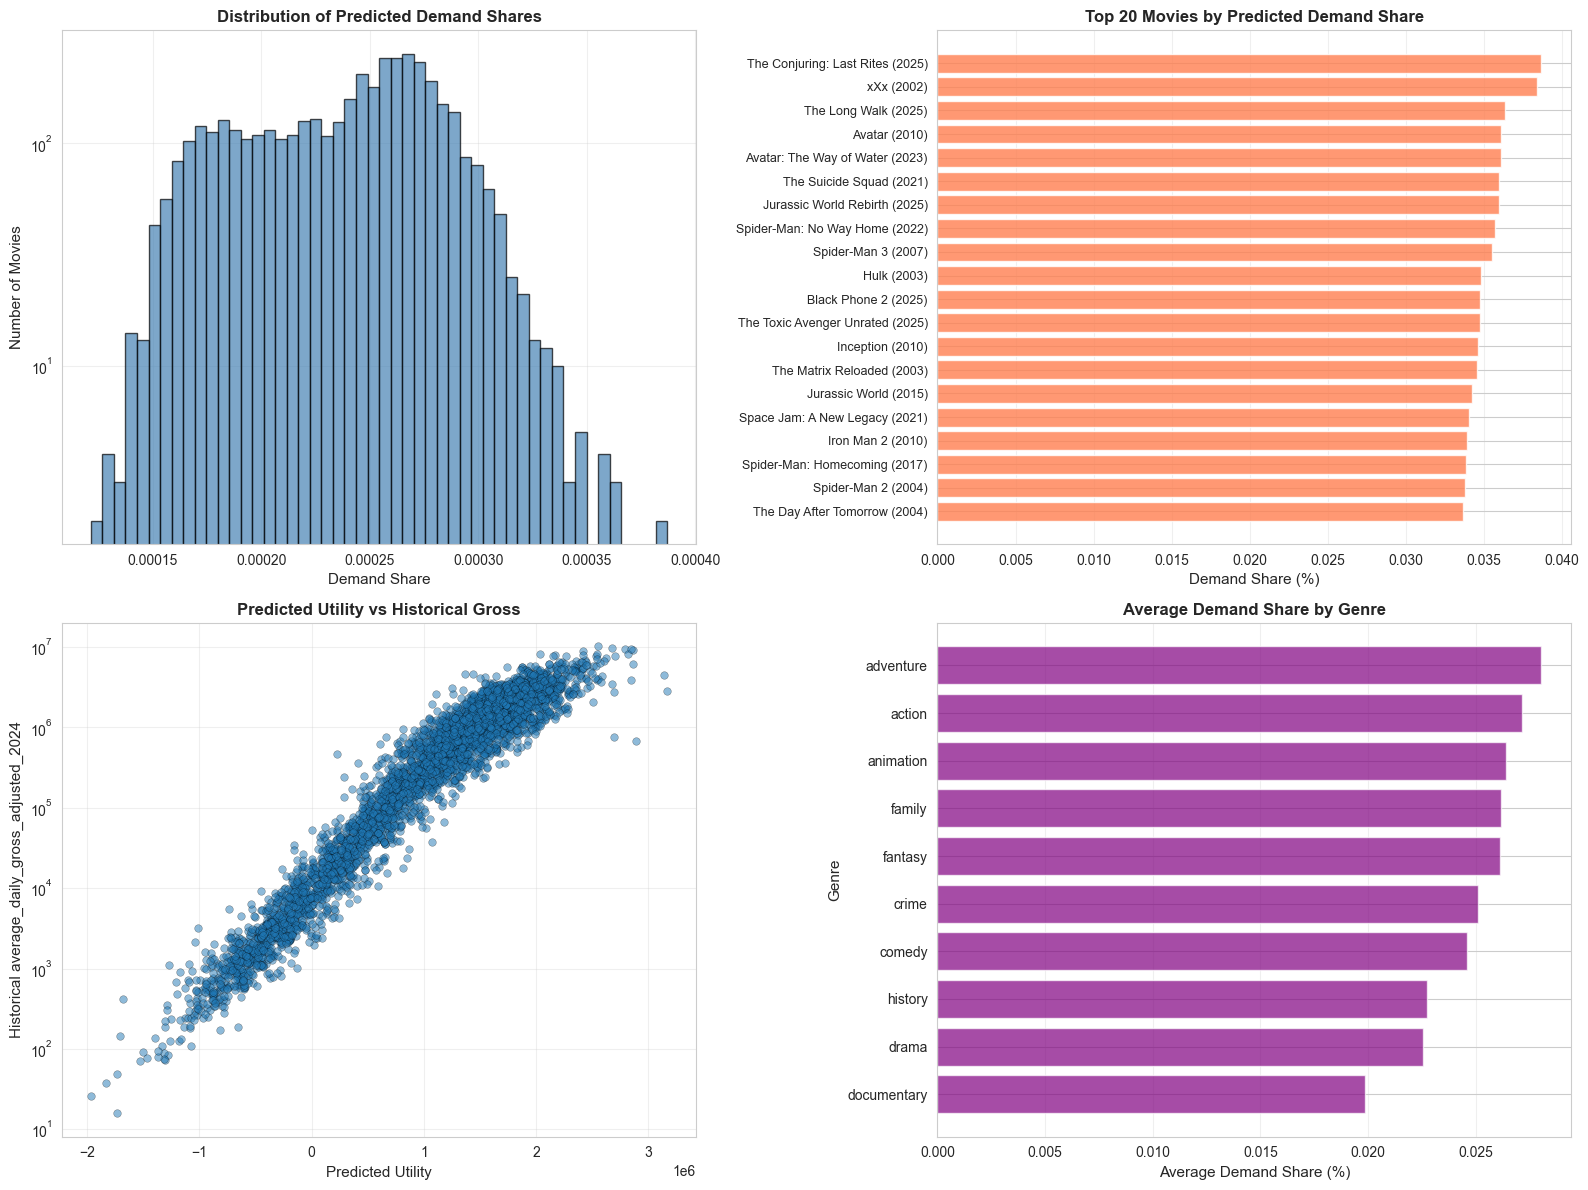

In [72]:
# ============================================================================
# 📈 VISUALIZATION SET 1: Four-Panel Results Dashboard
# ============================================================================
# This cell creates 4 visualizations in a 2x2 grid:
# 1. Distribution of Demand Shares (Histogram) - Top Left
# 2. Top 20 Movies by Demand Share (Bar Chart) - Top Right
# 3. Predicted Utility vs Historical Gross (Scatter) - Bottom Left
# 4. Average Demand Share by Genre (Bar Chart) - Bottom Right
# Use these in your Results section (Section 4)
# ============================================================================

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # ========================================================================
    # 📈 FIGURE 1: Distribution of Predicted Demand Shares (Histogram)
    # ========================================================================
    # Shows the distribution of demand shares across all 4,195 movies
    # Validates that probabilities are properly distributed (no single movie dominates)
    # Use in Results section (Section 4.3)
    # ========================================================================
axes[0, 0].hist(df_choice_clean['demand_share'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Demand Share', fontsize=11)
axes[0, 0].set_ylabel('Number of Movies', fontsize=11)
axes[0, 0].set_title('Distribution of Predicted Demand Shares', fontsize=12, fontweight='bold')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

    # ========================================================================
    # 📈 FIGURE 2: Top 20 Movies by Predicted Demand Share (Horizontal Bar)
    # ========================================================================
    # Visual ranking of top 20 movies by demand share percentage
    # Use in Results section (Section 4.4) as visual complement to Table 3
    # ========================================================================
top_20 = predictions.head(20)
axes[0, 1].barh(range(len(top_20)), top_20['demand_share'] * 100, color='coral', alpha=0.8)
axes[0, 1].set_yticks(range(len(top_20)))
axes[0, 1].set_yticklabels([f"{row['title'][:30]} ({int(row['year'])})" for _, row in top_20.iterrows()], fontsize=9)
axes[0, 1].set_xlabel('Demand Share (%)', fontsize=11)
axes[0, 1].set_title('Top 20 Movies by Predicted Demand Share', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

    # ========================================================================
    # 📈 FIGURE 3: Predicted Utility vs Historical Gross (Scatter Plot)
    # ========================================================================
    # Validates that utility predictions align with historical performance
    # Shows positive correlation between predicted utility and historical gross
    # Use in Results section (Section 4.1) to validate model alignment
    # ========================================================================
axes[1, 0].scatter(df_choice_clean['predicted_utility'], df_choice_clean[target_name],
                      alpha=0.5, s=30, edgecolors='black', linewidth=0.3)
axes[1, 0].set_xlabel('Predicted Utility', fontsize=11)
axes[1, 0].set_ylabel(f'Historical {target_name}', fontsize=11)
axes[1, 0].set_title('Predicted Utility vs Historical Gross', fontsize=12, fontweight='bold')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

    # ========================================================================
    # 📈 FIGURE 4: Average Demand Share by Genre (Horizontal Bar Chart)
    # ========================================================================
    # Shows which genres tend to have higher average demand shares
    # Provides insights into genre preferences
    # Use in Results section (Section 4.2) for genre analysis
    # ========================================================================
genre_demand = {}
for genre in available_genres[:10]:  # Top 10 genres
    genre_movies = df_choice_clean[df_choice_clean[genre] == 1]
    if len(genre_movies) > 0:
        genre_demand[genre] = genre_movies['demand_share'].mean()

if genre_demand:
    genres_sorted = sorted(genre_demand.items(), key=lambda x: x[1], reverse=True)
    genres_list = [g[0] for g in genres_sorted]
    demand_list = [g[1] * 100 for g in genres_sorted]
    
    axes[1, 1].barh(genres_list, demand_list, color='purple', alpha=0.7)
    axes[1, 1].set_xlabel('Average Demand Share (%)', fontsize=11)
    axes[1, 1].set_ylabel('Genre', fontsize=11)
    axes[1, 1].set_title('Average Demand Share by Genre', fontsize=12, fontweight='bold')
    axes[1, 1].invert_yaxis()
    axes[1, 1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    
    # Save the figure for use in write-up
    # Uncomment the line below to save:
    # plt.savefig('../predictions/results/results_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
    
    plt.show()


## 10. Model Interpretation: Feature Effects


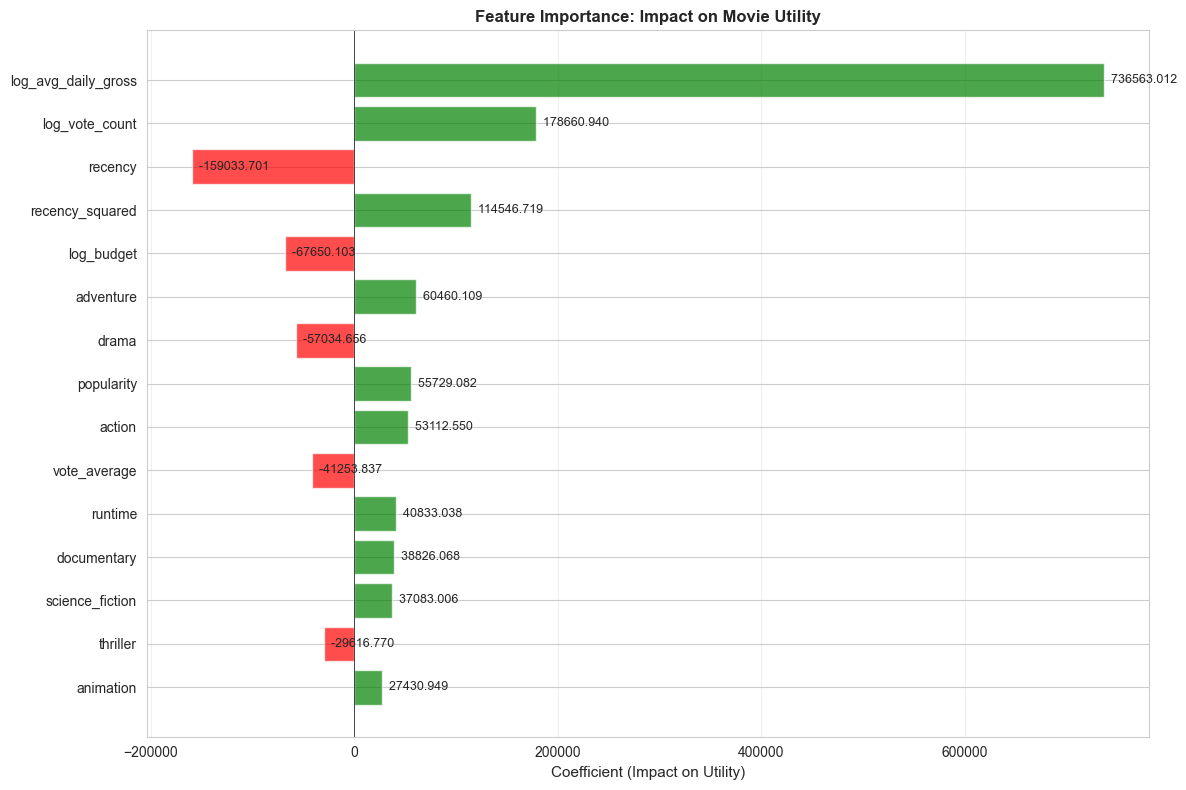

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

...

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>


Feature Interpretation:
Positive coefficients increase utility (make movie more attractive)
Negative coefficients decrease utility (make movie less attractive)

Top 5 Positive Features:
  log_vote_count                 +376184.271
  distributor_Warner Bros.       +185142.232
  distributor_Universal          +141071.185
  distributor_Sony Pictures      +137539.212
  ticker_PARA                    +122630.303

Top 5 Negative Features:
  distributor_Other              -183777.164
  distributor_Roadside Att…      -102337.823
  distributor_Paramount Va…      -94315.035
  recency                        -87668.058
  distributor_A24                -81139.370


In [73]:
# ============================================================================
# 📈 FIGURE 5: Feature Importance - Impact on Movie Utility (Bar Chart)
# ============================================================================
# Most important visualization! Shows which features increase/decrease utility
# Green bars = positive impact (increase attractiveness)
# Red bars = negative impact (decrease attractiveness)
# Use this as the PRIMARY visualization in your Results section (Section 4.2)
# ============================================================================

# Visualize feature importance from utility model
coef_df = feature_importance.copy()

fig, ax = plt.subplots(figsize=(12, 8))

top_features = coef_df.head(15)
colors = ['green' if x > 0 else 'red' for x in top_features['coefficient']]

ax.barh(range(len(top_features)), top_features['coefficient'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'], fontsize=10)
ax.set_xlabel('Coefficient (Impact on Utility)', fontsize=11)
ax.set_title('Feature Importance: Impact on Movie Utility', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linestyle='-', linewidth=0.5)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (idx, row) in enumerate(top_features.iterrows()):
    ax.text(row['coefficient'], i, f"  {row['coefficient']:.3f}", 
           va='center', fontsize=9)

    plt.tight_layout()
    
    # Save the figure for use in write-up
    # Uncomment the line below to save:
    # plt.savefig('../predictions/results/feature_importance.png', dpi=300, bbox_inches='tight', facecolor='white')
    
    plt.show()

print("\nFeature Interpretation:")
print("="*60)
print("Positive coefficients increase utility (make movie more attractive)")
print("Negative coefficients decrease utility (make movie less attractive)")
print("\nTop 5 Positive Features:")
for _, row in top_features[top_features['coefficient'] > 0].head(5).iterrows():
    print(f"  {row['feature']:<30} +{row['coefficient']:.3f}")
print("\nTop 5 Negative Features:")
for _, row in top_features[top_features['coefficient'] < 0].head(5).iterrows():
    print(f"  {row['feature']:<30} {row['coefficient']:.3f}")


## 11. Integration with Forecasting Model

This function can be used with your teammate's total demand forecast.


In [74]:
def predict_movie_demand_shares(total_demand_forecast, movies_available):
    """
    Main function to predict demand shares for available movies using utility-based MNL model.
    
    This integrates with:
    - Time series forecasting (total_demand_forecast from teammate)
    - Optimization model (movies_available - which movies are being shown)
    
    Parameters:
    -----------
    total_demand_forecast : float
        Total predicted demand from time series forecasting model
    movies_available : DataFrame
        Movies that are available/being shown (subset of full dataset)
        Must have all required feature columns
    
    Returns:
    --------
    demand_predictions : DataFrame
        Movies with predicted demand share and expected demand
    """
    # Ensure movies_available has all required features
    missing_cols = [c for c in feature_cols if c not in movies_available.columns]
    if missing_cols:
        print(f"Warning: Missing columns in movies_available: {missing_cols}")
        # Try to fill from main dataset
        if 'title_key' in movies_available.columns and 'title_key' in df_choice_clean.columns:
            for col in missing_cols:
                if col in df_choice_clean.columns:
                    # Merge missing columns
                    movies_available = movies_available.merge(
                        df_choice_clean[['title_key', col]].drop_duplicates(),
                        on='title_key',
                        how='left'
                    )
        else:
            # Fill with 0 if can't merge
            for col in missing_cols:
                movies_available[col] = 0
    
    # Use the predict_demand_shares function
    return predict_demand_shares(movies_available, choice_model, total_demand_forecast)

In [87]:

# ============================================================================
# 📊 TABLE 5: Example Predictions - Top Movies Scenario
# ============================================================================
# Shows example predictions for a scenario with 10 available movies
# and 50,000 total demand
# This demonstrates how the model works in practice
# Use this table in your Results section (Section 4.4) as a concrete example
# ============================================================================

# Example usage
print("Example: Predicting demand for a subset of movies")
print("="*60)

# Simulate: 10 random movies available
np.random.seed(42)
available_movies = df_choice_clean.sample(10, random_state=42)
total_demand = 25000  # Example from time series forecast

demand_predictions = predict_movie_demand_shares(total_demand, available_movies)

print(f"\nTotal Forecasted Demand: {total_demand:,}")
print(f"Number of Movies Available: {len(available_movies)}")
print(f"\nPredicted Demand Shares:")
print(demand_predictions.to_string(index=False))
print(f"\nTotal Expected Demand: {demand_predictions['expected_demand'].sum():,.0f}")

Example: Predicting demand for a subset of movies

Total Forecasted Demand: 25,000
Number of Movies Available: 10

Predicted Demand Shares:
               title release_date  year  runtime  action  adventure  animation  comedy  crime  documentary  drama  family  fantasy  history  horror  music  mystery  romance  science_fiction  thriller  tv_movie  war  western  predicted_utility  demand_share  expected_demand  expected_demand_pct
       A Simple Wish   1997-07-10  1997     86.0       0          1          0       1      0            0      0       1        1        0       0      0        0        0                0         0         0    0        0       1.387574e+06      0.164731      4118.272143            16.473089
                Hush   1998-03-05  1998     95.0       0          0          0       0      0            0      1       0        0        0       0      0        0        0                0         1         0    0        0       1.358808e+06      0.161661      4041.512

### 15 most recent movies

In [88]:
df_choice_clean.sort_values(by='release_date', ascending=False).head(20)

,ticker,date,title,distributor,gross,percent_yd,percent_lw,theaters,per_theater,total_gross,days_in_release,parent company,release_date,year,title_key,weekday,release_month,release_weekday,is_weekend,days_since_release,average_theaters,average_daily_gross,average_daily_gross_per_theater,total_gross_by_average_theaters,avg_gross_monday,avg_gross_tuesday,avg_gross_wednesday,avg_gross_thursday,avg_gross_friday,avg_gross_saturday,avg_gross_sunday,avg_gross_weekend,avg_gross_weekday,gross_per_theater_by_total,weekly_gross_by_total,average_weekly_gross,average_weekly_gross_per_theater,tmdb_id,popularity,imdb_id,original_language,status,budget,revenue,adult,overview,runtime,vote_average,vote_count,origin_country,spoken_languages,genre_ids,genre_names,production_company_ids,production_company_names,belongs_to_collection,omdb_title,omdb_year,omdb_rated,omdb_released,omdb_runtime,omdb_genre,omdb_director,omdb_writer,omdb_actors,omdb_plot,omdb_language,omdb_country,omdb_awards,omdb_poster,omdb_metascore,omdb_imdbrating,omdb_imdbvotes,omdb_boxoffice,omdb_production,omdb_rating_internetmoviedatabase,omdb_rating_rottentomatoes,omdb_rating_metacritic,release_year,cpi_release_year,inflation_factor,gross_adjusted_2024,total_gross_adjusted_2024,per_theater_adjusted_2024,budget_adjusted_2024,revenue_adjusted_2024,average_daily_gross_adjusted_2024,average_daily_gross_per_theater_adjusted_2024,gross_per_theater_by_total_adjusted_2024,average_weekly_gross_adjusted_2024,average_weekly_gross_per_theater_adjusted_2024,omdb_boxoffice_clean,omdb_boxoffice_adjusted_2024,genres_list,action,adventure,animation,comedy,crime,documentary,drama,family,fantasy,history,horror,music,mystery,romance,science_fiction,thriller,tv_movie,war,western,recency,recency_squared,log_vote_count,log_avg_daily_gross,log_budget,rt_rating,imdb_rating,release_year_month,choice_set_id,gross_rank,chosen,predicted_utility,demand_share
266,Private,2025-11-06,Anniversary,Roadside Att…,23223,-0.50,-0.43,809.0,29.0,530320,9,Roadside Attractions,2025-10-28,2025,anniversary,3,10,1,0,34,809.000000,2.322300e+04,29.000000,655.525340,0.000000e+00,0.000000e+00,0.000000e+00,2.322300e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.322300e+04,655.525340,5.303200e+05,1.625610e+05,203.000000,210832,0.0773,tt0224619,en,Released,0.0,0.0,False,Computer animated short film created to commem...,12.0,0.000,0.0,US,NaN,16,Animation,10473,ONF | NFB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,313.0,1.0,23223.0,530320.0,29.0,0.0,0.0,2.322300e+04,29.000000,655.525340,1.625610e+05,203.000000,NaN,NaN,['animation'],0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9,81,0.000000,10.052942,0.000000,0.0,0.0,2025-10,342,11.0,0,1.921739e+05,0.000198
2876,Private,2025-11-10,Stitch Head,Briarcliff E…,80111,-0.70,-0.47,1605.0,50.0,3943550,13,Briarcliff Entertainmen,2025-10-28,2025,stitch head,0,10,1,0,34,2010.090909,3.331274e+05,164.818182,1961.876442,1.152375e+05,3.011120e+05,1.039160e+05,1.394490e+05,3.500000e+05,6.800000e+05,5.200000e+05,5.500000e+05,1.524002e+05,1961.876442,3.943550e+06,2.331892e+06,1153.727273,1214130,4.1370,tt26720001,en,Released,34800000.0,3455841.0,False,Stitch Head was the first creature brought to ...,92.0,6.600,5.0,"FR, DE, LU, GB",English,"16, 12, 10751, 35","Animation, Adventure, Family, Comedy","150709, 229487, 142311, 56913, 50164, 191, 162...","GFM Animation, Rabbits Black, Aniventure, GRIN...",NaN,Stitch Head,2025.0,PG,29 Oct 2025,89 min,"Animation, Comedy, Family",Steve Hudson,"Guy Bass, Steve Hudson","Asa Butterfield, Joel Fry, Alison Steadman","Follows Stitch Head, a small creature awoken b...",English,"United Kingdom, France, Germany, Luxembourg",2 nominations total,https://m.media-amazon.com/images/M/MV5BYWUwNW...,NaN,6.1,182,NaN,NaN,6.1/10,69%,NaN,2025,313.0,1.0,80111.0,3943550.0,50.0,34800000.0,3455841.0,3.331274e+05,164.818182,1961.876442,2.331892e+06,1153.727273,NaN,NaN,"['animation', 'adventure', 'family', 'comedy']",0,1,1,1,0,0

In [85]:
print("15 most recent movies: ")

recent_movies = df_choice_clean.sort_values(by='release_date', ascending=False).head(15)
print(recent_movies['title'].tolist())

15 most recent movies: 
['Anniversary', 'Stitch Head', 'Last Days', 'Regretting You', 'Shelby Oaks', 'Black Phone 2', 'The Mastermind', 'Good Fortune', 'Truth & Treason', 'Re-Election', 'Soul on Fire', 'Kiss of the Spider Woman', 'Roofman', 'The Smashing Machine', 'Dead of Winter']


In [84]:
recent_demand_predictions = predict_movie_demand_shares(total_demand,recent_movies)

In [79]:
recent_demand_predictions['id'] = recent_demand_predictions.index
recent_demand_predictions.reset_index(drop=True, inplace=True)

In [80]:
recent_demand_predictions.head()

,title,release_date,year,runtime,action,adventure,animation,comedy,crime,documentary,drama,family,fantasy,history,horror,music,mystery,romance,science_fiction,thriller,tv_movie,war,western,predicted_utility,demand_share,expected_demand,expected_demand_pct,id
0,The Conjuring: Last Rites,2025-09-04,2025,136.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3.167556e+06,0.072567,3628.373276,7.256747,3138
1,The Long Walk,2025-09-11,2025,108.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,2.892415e+06,0.067002,3350.104537,6.700209,3451
2,Black Phone 2,2025-10-16,2025,114.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,2.696900e+06,0.063309,3165.436169,6.330872,471
3,One Battle After Another,2025-09-25,2025,162.0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2.206905e+06,0.054922,2746.119147,5.492238,2249
4,Regretting You,2025-10-23,2025,116.0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1.829314e+06,0.049226,2461.286918,4.922574,2486


In [81]:
recent_demand_predictions.to_csv('../data/predictions/recent_demand_predictions.csv')

## 13. Integration with Optimization Model

This section shows how to connect your choice model output to the optimization model's input format.

**Workflow:**
1. **Time Series Model** → Provides `total_demand_forecast` (total customers expected)
2. **Choice Model (YOU)** → Converts total demand into demand shares per movie
3. **Optimization Model** → Uses demand per movie to schedule showtimes

**Key Integration Point:** The optimization model needs demand in the format:
```python
demand = {
    (movie_id, "Mon"): daily_demand_value,
    (movie_id, "Tue"): daily_demand_value,
    ...
}
```

**Note:** You can work independently! You don't need to wait for the time series model:
- ✅ Test your model with example total demand values 
- ✅ Validate predictions on historical data
- ✅ Your model accepts any `total_demand_forecast` value - just plug it in when ready
- ⏳ For final integration, you'll need: (1) total demand from time series, (2) available movies list


In [ ]:
def prepare_demand_for_optimization(choice_model_predictions, total_weekly_demand, days=None):
    """
    Convert choice model predictions to optimization model's demand format.
    
    This function takes your choice model's output and formats it for the optimization model.
    
    Parameters:
    -----------
    choice_model_predictions : DataFrame
        Output from predict_movie_demand_shares() with columns:
        - 'title' or 'movie_id': Movie identifier
        - 'expected_demand': Total expected demand for the week
        - Any other columns (will be preserved in metadata)
    total_weekly_demand : float
        Total weekly demand (should match sum of expected_demand)
    days : list, optional
        Days of the week. Default: ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    
    Returns:
    --------
    demand_dict : dict
        Dictionary with (movie_id, day) tuples as keys and daily demand as values
        Format: {(movie_id, "Mon"): demand_value, ...}
    metadata : DataFrame
        Additional information about movies (title, weekly demand, etc.)
    """
    if days is None:
        days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    
    # Daily demand distribution (weekends get more demand)
    # These weights sum to 7 (representing 7 days)
    daily_weights = {
        "Mon": 0.8,
        "Tue": 0.8,
        "Wed": 0.9,
        "Thu": 1.0,
        "Fri": 1.3,
        "Sat": 1.6,
        "Sun": 1.6
    }
    
    # Create demand dictionary for optimization model
    demand_dict = {}
    
    # # Get movie identifier column
    # if 'movie_id' in choice_model_predictions.columns:
    #     id_col = 'movie_id'
    # elif 'title_key' in choice_model_predictions.columns:
    #     id_col = 'title_key'
    # elif 'title' in choice_model_predictions.columns:
    #     # Use index if no explicit ID column
    #     id_col = None
    # else:
    #     # Use index as movie_id
    #     id_col = None
    
    for idx, row in choice_model_predictions.iterrows():
        # Get movie identifier
        # if id_col:
        #     movie_id = row[id_col]
        # else:
        #     movie_id = idx
        
        # Get weekly expected demand from choice model
        weekly_demand = row['expected_demand']
        
        # Distribute weekly demand across days based on weights
        for day in days:
            # Each day gets its weighted share of weekly demand
            daily_demand = int(weekly_demand * daily_weights[day] / 7.0)
            demand_dict[(movie_id, day)] = daily_demand
    
    # Create metadata DataFrame
    metadata = choice_model_predictions.copy()
    if 'movie_id' not in metadata.columns and id_col:
        metadata['movie_id'] = metadata[id_col]
    elif 'movie_id' not in metadata.columns:
        metadata['movie_id'] = metadata.index
    
    return demand_dict, metadata

print("✓ Integration function created: prepare_demand_for_optimization()")
print("\nThis function converts your choice model output to the optimization model's input format.")


In [ ]:
## Example: Full Integration Workflow

# Step 1: Get total demand forecast from time series model
# (In practice, this comes from your teammate's time series forecasting)
total_weekly_demand = 50000  # Example: 50,000 customers per week

# Step 2: Get available movies (from optimization model or current releases)
# This should be a subset of movies that are available/being considered
available_movies = df_choice_clean.sample(10, random_state=42).copy()

# Step 3: Use choice model to predict demand shares
print("Step 1-3: Using Choice Model to Predict Demand Shares")
print("="*60)
demand_predictions = predict_movie_demand_shares(total_weekly_demand, available_movies)

print(f"\nTotal Forecasted Demand: {total_weekly_demand:,} customers/week")
print(f"Number of Movies Available: {len(available_movies)}")
print(f"\nPredicted Demand Shares (Top 5):")
print(demand_predictions.head(5)[['title', 'year', 'demand_share', 'expected_demand']].to_string(index=False))
print(f"\nTotal Expected Demand: {demand_predictions['expected_demand'].sum():,.0f} customers/week")

# Step 4: Convert to optimization model format
print("\n" + "="*60)
print("Step 4: Converting to Optimization Model Format")
print("="*60)

# Need to add movie_id to predictions for optimization model
# (In practice, this would come from the optimization model's movie list)
demand_predictions_with_id = demand_predictions.copy()
demand_predictions_with_id['movie_id'] = range(len(demand_predictions_with_id))

# Convert to optimization format
demand_dict, metadata = prepare_demand_for_optimization(
    demand_predictions_with_id,
    total_weekly_demand
)

print(f"\n✓ Created demand dictionary with {len(demand_dict)} entries")
print(f"  Format: (movie_id, day) → daily_demand")
print(f"\nExample entries:")
for i, ((movie_id, day), demand_val) in enumerate(list(demand_dict.items())[:5]):
    movie_title = metadata[metadata['movie_id'] == movie_id]['title'].iloc[0] if len(metadata) > 0 else f"Movie {movie_id}"
    print(f"  ({movie_id}, {day}): {demand_val} tickets/day  [{movie_title[:30]}]")

# Step 5: Show daily demand breakdown for one movie
print(f"\n" + "="*60)
print("Step 5: Daily Demand Breakdown (Example Movie)")
print("="*60)
example_movie_id = list(demand_dict.keys())[0][0]
example_movie_title = metadata[metadata['movie_id'] == example_movie_id]['title'].iloc[0] if len(metadata) > 0 else f"Movie {example_movie_id}"
print(f"\nMovie: {example_movie_title} (ID: {example_movie_id})")
print(f"Weekly Expected Demand: {demand_predictions_with_id[demand_predictions_with_id['movie_id'] == example_movie_id]['expected_demand'].iloc[0]:,.0f} customers")
print(f"\nDaily Demand Distribution:")
for day in ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]:
    daily_demand = demand_dict.get((example_movie_id, day), 0)
    print(f"  {day}: {daily_demand} tickets/day")

print(f"\n" + "="*60)
print("INTEGRATION COMPLETE")
print("="*60)
print(f"\nThe 'demand_dict' is now ready to be passed to the optimization model!")
print(f"\nIn the optimization notebook, replace:")
print(f"  demand = {{(movie_id, day): value, ...}}  # Current: from historical gross")
print(f"with:")
print(f"  demand = demand_dict  # From choice model predictions")


In [ ]:
## Integration Helper Function

# The prepare_demand_for_optimization() function is defined in Cell 27 above.
# You can use it directly in this notebook or copy it to the optimization notebook when ready.

print("✓ Integration function 'prepare_demand_for_optimization()' is available in this notebook")
print("\nTo use it:")
print("  1. Call prepare_demand_for_optimization(choice_predictions, total_weekly_demand)")
print("  2. Pass the resulting demand_dict to the optimization model")
print("\nNote: When ready to export, you can save this function to a .py file for use in other notebooks.")


In [ ]:
# Save predictions for all movies
output_df = df_choice_clean[['title', 'year', 'runtime', 'recency', 'vote_average', 
                            target_name, 'predicted_utility', 'demand_share']].copy()

# Add genre information
for genre in available_genres:
    if genre in df_choice_clean.columns:
        output_df[genre] = df_choice_clean[genre]

# Save to CSV
import os
results_dir = '../predictions/results'
os.makedirs(results_dir, exist_ok=True)

output_path = os.path.join(results_dir, 'choice_model_predictions.csv')
output_df.to_csv(output_path, index=False)
print(f"✓ Saved predictions to {output_path}")
print(f"  Rows: {len(output_df):,}")
print(f"  Columns: {len(output_df.columns)}")

# Save model components (for later use)
import pickle

model_components = {
    'utility_model': choice_model['utility_model'],
    'scaler': choice_model['scaler'],
    'feature_cols': choice_model['feature_cols'],
    'target_name': target_name
}

model_path = os.path.join(results_dir, 'choice_model_components.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model_components, f)

print(f"✓ Saved model components to {model_path}")

print("\n" + "="*60)
print("MODEL READY FOR USE")
print("="*60)
print("\nTo use this model with your teammate's forecasts:")
print("  1. Get total_demand_forecast from time series model")
print("  2. Get movies_available from optimization model")
print("  3. Call: predict_movie_demand_shares(total_demand_forecast, movies_available)")
print("\nThe function returns demand shares and expected demand for each movie.")
